In [25]:
from numpy.random import default_rng
import numpy as np
import matplotlib.pyplot as plt
###################################

from pathlib import Path # para trabajar con rutas
import sys #información del sistema

ROOT = Path.cwd() # variable ROOT = current working directory
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent #reemplazamos el valor de ROOT por su padre hasta encontrar src

sys.path.insert(0, str(ROOT))

####################################

In [3]:
ROOT
ROOT.parent.parent.parent


WindowsPath('c:/Users/JHOSSEP/Documents')

In [33]:
# exportamos las funciones
from src.simuladorBJPC import BJPCPlan, simulate_bjpc_exp_suffstats
from src.priors import GammaPrior, BetaPrior, BetaGammaPrior
from src.posterior import BetaGammaPosterior
from src.loss import WarrantyTargets, AcceptanceWeights, g_exp_fail_before_L, SamplingCosts
from src.bayesRisk import ExponentialBayesRisk, SimulatedBayesRisk

In [11]:
############################### DATA BJPC #####################################
# Fijamos el plan experimental
# n=7: empiezo con 7 unidades del producto 1 y 7 unidades del porducto 2, 
# k=6: el experimento NO espera a que fallen todas las unidades, termina en la 6ta falla, esto es censura 
# es decir que si las fallas son k1 y k2, k1+k2=6, entonces el experimento termina
# R=[1,0,0,0,0]: después de la primera falla retiro una unidad adicional, 
# después de la segunda falla no retiro nada (0), después de la tercera falla no retiro nada (0) etc. (0,0)

plan = BJPCPlan(n=7, k=6, R=[1,0,0,0,0])
rng = default_rng(123)

data = simulate_bjpc_exp_suffstats(plan, lambda1=0.06, lambda2=0.03, rng=rng)
data

# hubo k1 fallas del producto 1, k2 fallas del producto 2. t_end es el tiempo en el que ocurrió la ultima falla

{'k1': 4, 'k2': 2, 'u': 73.51248704224477, 't_end': 30.2922991916515}

In [14]:
################################## PRIOR #####################################
gamma_prior = GammaPrior(a0=2.0, b0=1.5)
beta_prior  = BetaPrior(a1=2.0, a2=3.0)

bg_prior = BetaGammaPrior(gamma_prior=gamma_prior, beta_prior=beta_prior)

lambda1, lambda2 = bg_prior.sample(size=4)
print(lambda1, lambda2)

[0.19410109 0.02539213 0.90491067 0.06849181] [0.57121499 0.09217465 0.64241087 0.09529977]


In [18]:
############################### POSTERIOR #####################################
# usamos la fórmmula de la posterior actualizada ya conocida ya que es una conjugada y muestramos lamda1 y lambda2 a partir de la posterior

post = BetaGammaPosterior(
    a0=2.0, b0=1.5,
    a1=2.0, a2=3.0,
    k1=data["k1"], 
    k2=data["k2"], 
    u=data["u"]
)

# Muestrear lambda1, lambda2 
rng = default_rng(123)
lambda1_s, lambda2_s = post.sample(size=10000, rng=rng)

print(lambda1_s.mean(), lambda2_s.mean())

0.05813428568847214 0.04889126414996703


In [19]:
############################### LOSS #####################################
#Pero una acción no se toma por las tasas si no por el costo esperado de cada acción
# aceptamos o rechazamos el lote?


targets = WarrantyTargets(L1=100.0, L2=100.0)     # vida/garantía
weights = AcceptanceWeights(C1=200.0, C2=200.0)   # costo por falla temprana
# si el producto 1 falla antes de su vida objetivo, le asignas un costo 200.
# lo mismo para el producto 2. (C1 y C2)

#cálculo de g para cada posterior
g_s = g_exp_fail_before_L(
    lambda1=lambda1_s,
    lambda2=lambda2_s,
    targets=targets,
    weights=weights
)

phi = float(g_s.mean())
phi

# phi es la pérdida posterior esperada, o el costo posterior esperado asociado al desempeño del lote respecto a la garantía.

388.2001881205323

In [20]:
############################### DECISION #####################################
"""
Aceptas si 𝜙 < 𝐶𝑟
Rechazas si 𝜙 ≥ 𝐶𝑟
"""
print

Cr = 150.0
accept = phi < Cr

print("phi =", phi, "| decision =", "ACCEPT" if accept else "REJECT")


# Rechazo el lote, en esta oportunidad solo estamos evaluando 1 lote 

phi = 388.2001881205323 | decision = REJECT


In [ ]:
############################### RIESGO DE BAYES #####################################
# “Si uso esta regla de decisión y este plan (n,k,R), ¿cuánto me cuesta EN PROMEDIO antes de ver datos?” 
# así elegimos el mejor plan (n,k,R) y la mejor regla de decisión (Cr) antes de ver datos, minimizando el riesgo de Bayes previo a la experimentación.

# EL RIESGO DE BAYES VUELVE A SIMULAR TODO_NUEVAMENTE, anteriormente hicimos un experimento (6 vueltas) ahora harems varios

# SIMULACIÓN DEL RIESGO BAYESIANO

In [22]:
# ============================================================================
# CONTEXTO 
# ============================================================================
#
# Tenemos DOS productos (P1 y P2) que queremos evaluar.
# Cada producto tiene una TASA DE FALLA (λ1 y λ2) que NO conocemos.
#
#   - Si λ es PEQUEÑA → el producto dura mucho (buena calidad)
#   - Si λ es GRANDE → el producto falla rápido (mala calidad)
#
# Podemos hacer un EXPERIMENTO (test de vida) para obtener información.
# Pero el experimento CUESTA dinero y tiempo.
#
# Al final, debemos DECIDIR:
#   - ACEPTAR ambos lotes (venderlos)
#   - RECHAZAR ambos lotes (desecharlos)
#
# El RIESGO DE BAYES es el COSTO ESPERADO TOTAL de todo este proceso.
#
# ============================================================================

print("\n" + "="*60)
print("CONTEXTO DEL PROBLEMA")
print("="*60)
print("""
Queremos decidir si aceptar o rechazar dos lotes de productos.
- Si los productos son buenos (λ pequeña) → queremos aceptar
- Si los productos son malos (λ grande) → queremos rechazar

Pero no conocemos λ. Tenemos que hacer un experimento para aprender.
El experimento cuesta dinero. El riesgo de Bayes nos dice el costo esperado.
""")


CONTEXTO DEL PROBLEMA

Queremos decidir si aceptar o rechazar dos lotes de productos.
- Si los productos son buenos (λ pequeña) → queremos aceptar
- Si los productos son malos (λ grande) → queremos rechazar

Pero no conocemos λ. Tenemos que hacer un experimento para aprender.
El experimento cuesta dinero. El riesgo de Bayes nos dice el costo esperado.



In [23]:
# ============================================================================
#  DEFINIR EL PLAN DE MUESTREO (BJPC)
# ============================================================================
#
# n = 7: Ponemos 7 unidades de P1 y 7 de P2 en el test
# k = 6: El test termina cuando hayamos visto 6 fallas en TOTAL
# R = [1,0,0,0,0]: Después de la primera falla, retiramos 1 unidad extra
#
# ¿Por qué este plan? Es un ejemplo. Luego buscaremos el mejor plan optimizando el riesgo de Bayes :)
#
# ============================================================================

plan = BJPCPlan(
    n=7,                # 7 unidades de cada producto
    k=6,                # terminamos en la 6ta falla
    R=[1, 0, 0, 0, 0]   # retiramos 1 después de la primera falla
)

print("\n" + "="*60)
print("PLAN DE MUESTREO BJPC")
print("="*60)
print(f"  n (unidades por producto): {plan.n}")
print(f"  k (fallas totales a observar): {plan.k}")
print(f"  R (retiros después de cada falla): {plan.R}")


PLAN DE MUESTREO BJPC
  n (unidades por producto): 7
  k (fallas totales a observar): 6
  R (retiros después de cada falla): [1, 0, 0, 0, 0]



PRIOR (Creencias iniciales)
  λ ~ Gamma(a0=2.0, b0=1.5)
    → E[λ] = 1.33
    → Var[λ] = 0.89

  p ~ Beta(a1=2.0, a2=2.5)
    → E[p] = 0.44
    → E[1-p] = 0.56


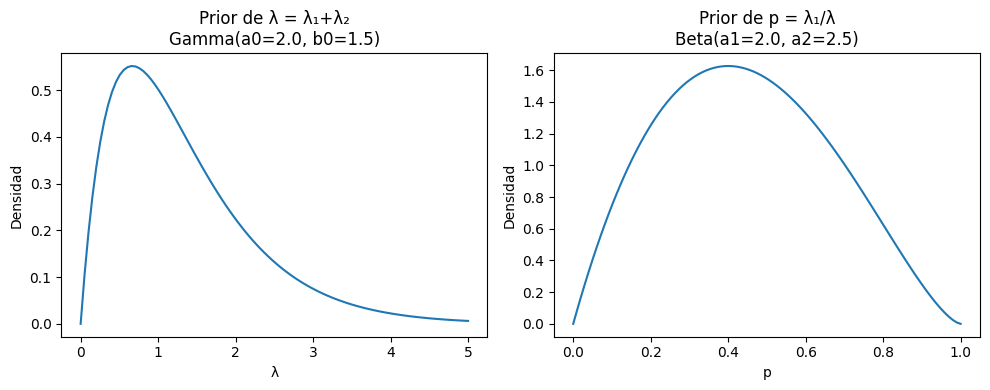

In [26]:
# ============================================================================
# PRIOR
# ============================================================================
#
# Usamos el prior BETA-GAMMA:
#
#   λ = λ1 + λ2  ~  Gamma(a0, b0)     (tasa total de fallas)
#   p = λ1/λ     ~  Beta(a1, a2)       (proporción de P1)
#
# Hiperparámetros elegidos:
#   a0 = 2.0, b0 = 1.5
#   a1 = 2.0, a2 = 2.5
#
# ¿Qué significan estos números?
#   - E[λ] = a0/b0 = 2/1.5 ≈ 1.33 (tasa total esperada)
#   - E[p] = a1/(a1+a2) = 2/4.5 ≈ 0.44 (44% de fallas vienen de P1)
#
# ============================================================================

# Definir el prior
gamma_prior = GammaPrior(a0=2.0, b0=1.5)   # para λ
beta_prior = BetaPrior(a1=2.0, a2=2.5)     # para p
prior = BetaGammaPrior(gamma_prior=gamma_prior, beta_prior=beta_prior)

print("\n" + "="*60)
print("PRIOR (Creencias iniciales)")
print("="*60)
print(f"  λ ~ Gamma(a0={gamma_prior.a0}, b0={gamma_prior.b0})")
print(f"    → E[λ] = {gamma_prior.a0/gamma_prior.b0:.2f}")
print(f"    → Var[λ] = {gamma_prior.a0/gamma_prior.b0**2:.2f}")
print()
print(f"  p ~ Beta(a1={beta_prior.a1}, a2={beta_prior.a2})")
s = beta_prior.a1 + beta_prior.a2
print(f"    → E[p] = {beta_prior.a1/s:.2f}")
print(f"    → E[1-p] = {beta_prior.a2/s:.2f}")

# Visualizar el prior (opcional)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Distribución de λ
lambda_vals = np.linspace(0, 5, 100)
from scipy.stats import gamma as gamma_dist
axes[0].plot(lambda_vals, gamma_dist.pdf(lambda_vals, a=gamma_prior.a0, scale=1/gamma_prior.b0))
axes[0].set_title(f'Prior de λ = λ₁+λ₂\nGamma(a0={gamma_prior.a0}, b0={gamma_prior.b0})')
axes[0].set_xlabel('λ')
axes[0].set_ylabel('Densidad')

# Distribución de p
p_vals = np.linspace(0, 1, 100)
from scipy.stats import beta as beta_dist
axes[1].plot(p_vals, beta_dist.pdf(p_vals, a=beta_prior.a1, b=beta_prior.a2))
axes[1].set_title(f'Prior de p = λ₁/λ\nBeta(a1={beta_prior.a1}, a2={beta_prior.a2})')
axes[1].set_xlabel('p')
axes[1].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

In [30]:
# ============================================================================
# DEFINIMOS COSTOS
# ============================================================================
#
# SamplingCosts: costos del experimento
#   - Cs: costo por unidad puesta en el test (0.3)
#   - rs1, rs2: valor de rescate por unidad que NO falla (0.1 cada una)
#   - Ctau: costo por unidad de tiempo que dura el test (0.05)
#   - Cr: costo fijo por rechazar el lote (40.0)
#
# WarrantyTargets: umbrales de garantía
#   - L1, L2: si un producto falla antes de este tiempo, es "falla temprana"
#
# AcceptanceWeights: costo por falla temprana
#   - C1, C2: cuánto cuesta que un producto tenga falla temprana (200 cada uno)
#
# ============================================================================

# Costos del experimento
costos = SamplingCosts(
    Cs=0.3,      # costo por unidad puesta en test
    rs1=0.1,     # salvage valor de P1 (lo recuperamos si no falla)
    rs2=0.1,     # salvage valor de P2
    Ctau=0.05,   # costo por tiempo de test
    Cr=40.0      # costo fijo de rechazar
)

# Parámetros para calcular g (costo de aceptar lotes malos)
targets = WarrantyTargets(L1=100.0, L2=100.0)   # umbral de garantía
pesos = AcceptanceWeights(C1=200.0, C2=200.0)   # costo por falla temprana

print("\n" + "="*60)
print("COSTOS DEFINIDOS")
print("="*60)
print(f"  Cs (costo por unidad): {costos.Cs}")
print(f"  rs1 (salvage P1): {costos.rs1}")
print(f"  rs2 (salvage P2): {costos.rs2}")
print(f"  Ctau (costo por tiempo): {costos.Ctau}")
print(f"  Cr (costo de rechazar): {costos.Cr}")
print()
print(f"  L1 (umbral garantía P1): {targets.L1}")
print(f"  L2 (umbral garantía P2): {targets.L2}")
print(f"  C1 (costo falla temprana P1): {pesos.C1}")
print(f"  C2 (costo falla temprana P2): {pesos.C2}")

# La función g(λ₁,λ₂)? es el COSTO DE ACEPTAR lotes de mala calidad.


COSTOS DEFINIDOS
  Cs (costo por unidad): 0.3
  rs1 (salvage P1): 0.1
  rs2 (salvage P2): 0.1
  Ctau (costo por tiempo): 0.05
  Cr (costo de rechazar): 40.0

  L1 (umbral garantía P1): 100.0
  L2 (umbral garantía P2): 100.0
  C1 (costo falla temprana P1): 200.0
  C2 (costo falla temprana P2): 200.0


In [37]:
################### RIESGO DE BAYES ###################

riesgo = ExponentialBayesRisk(
    n=7, k=6, R=[1,0,0,0,0],
    a0=2.0, b0=1.5, a1=2.0, a2=2.5,
    costs=costos,
    c0=0, c1=1, c2=1, c3=0, c4=0
)

resultado = riesgo.compute()
print(f"Riesgo = {resultado:.4f}")

Riesgo = 2.8153


In [ ]:
###################### OPTIMIZACIÓN ###############################